In [2]:
%matplotlib widget
import torch
import numpy as np
import matplotlib.pyplot as plt
from diffSPH.dataLoader import *
from diffSPH.plotting import visualizeParticles, updatePlot

In [12]:
folders = [
        #   '/home/winchenbach/dev/diffSPH16K/data/compressible/circularRegion/',
        #    '/home/winchenbach/dev/diffSPH16K/data/compressible/dualRegion/',
        #    '/home/winchenbach/dev/diffSPH16K/data/compressible/pressureDensity/',
        #    '/home/winchenbach/dev/diffSPH16K/data/compressible/quadRegion/',
        #    '/home/winchenbach/dev/diffSPH16K/data/compressible/velocity/',

        #    '/home/winchenbach/dev/diffSPH16K/data/weaklyCompressibleFreeSlip/both/',
        #    '/home/winchenbach/dev/diffSPH16K/data/weaklyCompressibleFreeSlip/domain/',
        #    '/home/winchenbach/dev/diffSPH16K/data/weaklyCompressibleFreeSlip/noBoundary/',
        #    '/home/winchenbach/dev/diffSPH16K/data/weaklyCompressibleFreeSlip/obstacle/',
         #   '/home/winchenbach/dev/diffSPH16K/data/weaklyCompressibleFreeSlip/TGV/',

           '/home/winchenbach/dev/diffSPH16K/data/weaklyCompressibleNoSlip/both/',
           '/home/winchenbach/dev/diffSPH16K/data/weaklyCompressibleNoSlip/domain/',
           '/home/winchenbach/dev/diffSPH16K/data/weaklyCompressibleNoSlip/noBoundary/',
           '/home/winchenbach/dev/diffSPH16K/data/weaklyCompressibleNoSlip/obstacle/',
         #   '/home/winchenbach/dev/diffSPH16K/data/weaklyCompressibleNoSlip/TGV/',

        #    '/home/winchenbach/servus05/dev/datasets_ssd/weaklyCompressible2/freeSlipTGV/data/',
        #    '/home/winchenbach/servus05/dev/datasets_ssd/weaklyCompressible2/noSlipTGV/data/',
        # '/home/winchenbach/servus05/dev/datasets_ssd/weaklyCompressible/freeSlipv2/data/'
]

In [13]:
configuration = DataConfiguration(
    frameDistance=1,
    frameSpacing=1,
    maxRollout=1,
    historyLength=1,
    skipInitialFrames=0,
    cutoff=0
)

processed = []

for folder in folders:
    p = processFolder(folder, configuration)
    processed.extend(p)
# processed = processFolder(folders[0], configuration)

for file in processed:
    print(f'File: {file["fileName"]}, FrameCount: {len(file["frames"])}, Samples: {len(file["samples"])}, Style: {file["style"]}, Number of samples: {len(processed[0]["samples"])}, first sample: {processed[0]["samples"][0]}, last sample: {processed[0]["samples"][-1]}')


File: /home/winchenbach/dev/diffSPH16K/data/weaklyCompressibleNoSlip/both//wcsph_True_True_0_16384_2025-08-14_13-17-56_1564495896.h5, FrameCount: 4095, Samples: 4095, Style: diffSPH, Number of samples: 4095, first sample: 000001, last sample: 004095
File: /home/winchenbach/dev/diffSPH16K/data/weaklyCompressibleNoSlip/both//wcsph_True_True_0_16384_2025-08-14_13-17-56_977620291.h5, FrameCount: 4095, Samples: 4095, Style: diffSPH, Number of samples: 4095, first sample: 000001, last sample: 004095
File: /home/winchenbach/dev/diffSPH16K/data/weaklyCompressibleNoSlip/both//wcsph_True_True_0_16384_2025-08-14_13-21-38_57492470.h5, FrameCount: 4095, Samples: 4095, Style: diffSPH, Number of samples: 4095, first sample: 000001, last sample: 004095
File: /home/winchenbach/dev/diffSPH16K/data/weaklyCompressibleNoSlip/both//wcsph_True_True_0_16384_2025-08-14_13-22-08_1311708935.h5, FrameCount: 4095, Samples: 4095, Style: diffSPH, Number of samples: 4095, first sample: 000001, last sample: 004095
Fil

In [14]:
dataset, datasetLoader = getDataLoader(processed, 4, shuffle = True)
datasetIter = iter(datasetLoader)

nextData = next(datasetIter)
print(f'Next data: {nextData}')

# nextData = [0, 16, 64, 98]
# nextData = [9000]

Next data: [39445, 121192, 150964, 1564]


In [15]:
import ipywidgets

dropdownFiles = ipywidgets.Dropdown(
    options=[f['fileName'] for f in processed],
    description='Files:',
    disabled=False,
    style={'description_width': 'initial'},
    layout=ipywidgets.Layout(width='50%'),
    value=processed[0]['fileName']  # Default value
)
frameSlider = ipywidgets.IntSlider(
    value=0,
    min=0,
    max=len(processed[0]['frames']) - 1,
    step=1,
    description='Frame:',
    continuous_update=False,
    style={'description_width': 'initial'},
    layout=ipywidgets.Layout(width='50%')
)

def updatePlots(plots, processed, frame):
    priorStates, currentState, trajectoryStates, domains, rotMats, configs, neighborhoods = loadAugmentedBatch(
        dataset, [(processed['fileName'],'%06d'%frame)], configuration, device = 'cuda', dtype = torch.float32,
        augmentAngle = False,
    )
    # s = 1

    updatePlot(plots[0], currentState, quantity=currentState.densities, domain = domains[0], markerSize = s)
    updatePlot(plots[1], currentState, quantity=currentState.internalEnergies if isinstance(currentState, CompressibleSPHState) else currentState.velocities, domain = domains[0], markerSize = s)
    updatePlot(plots[2], currentState, quantity=currentState.velocities, domain = domains[0], markerSize = s)
    updatePlot(plots[3], currentState, quantity=currentState.UIDs, domain = domains[0], markerSize = s)
    
    fig.suptitle(f'File: {processed["fileName"].split("/")[-1]}, Frame: {processed["frames"][frame]}, Samples: {len(processed["samples"])}, Style: {processed["style"]}, \nNumber of samples: {len(processed["samples"])}, first sample: {processed["samples"][0]}, last sample: {processed["samples"][-1]}')


def updatePlotFromDropdown(change):
    if change['new'] is not None:
        fileIndex = [f['fileName'] for f in processed].index(change['new'])
        frames = processed[fileIndex]['frames']

        priorFrames = int(frameSlider.max)
        newValue = np.clip(int(frameSlider.value / priorFrames * (len(frames) - 1)), 0, len(frames) - 1)
        frameSlider.max = len(frames) - 1
        frameSlider.value = newValue
        fig.suptitle(f'File: {change["new"].split("/")[-1]}, Frame: {frames[0]}, Samples: {len(processed[fileIndex]["samples"])}, Style: {processed[fileIndex]["style"]}, \nNumber of samples: {len(processed[fileIndex]["samples"])}, first sample: {processed[fileIndex]["samples"][0]}, last sample: {processed[fileIndex]["samples"][-1]}')
        updatePlots(plots, processed[fileIndex], frame=frameSlider.value)


def updatePlotFromSlider(change):
    if change['new'] is not None:
        fileIndex = [f['fileName'] for f in processed].index(dropdownFiles.value)
        updatePlots(plots, processed[fileIndex], frame=change['new'])


dropdownFiles.observe(updatePlotFromDropdown, names='value')
frameSlider.observe(updatePlotFromSlider, names='value')


  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

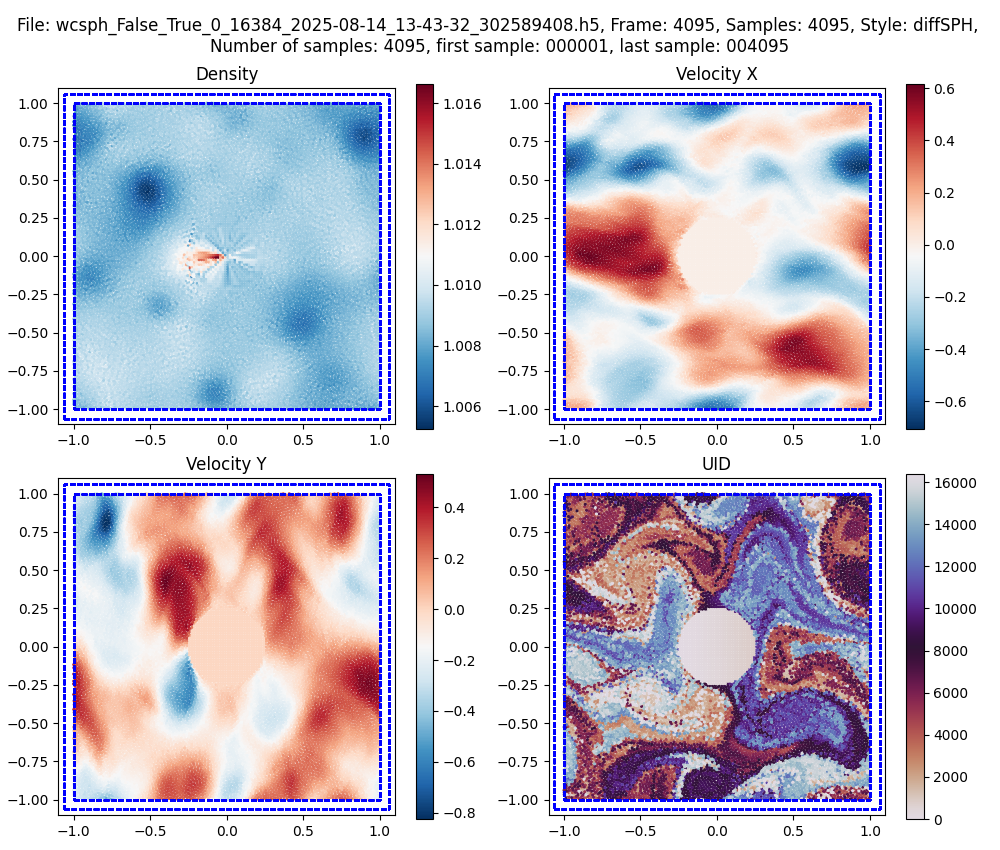

In [16]:
priorStates, currentState, trajectoryStates, domains, rotMats, configs, neighborhoods = loadAugmentedBatch(
    dataset, [(processed[0]['fileName'],'%06d'%0)], configuration, device = 'cuda', dtype = torch.float32,
    augmentAngle = False,
)

fig, axis = plt.subplots(2, 2, figsize=(10, 8.5), squeeze = False)
# filteredNeighborhood = filterNeighborhoodByKind(currentStates[0], neighborhoods[0], 'noghost')

plots = []
axes = axis.flatten()

s = 1.5

densityPlot = visualizeParticles(fig, axes[0],
                            particles = currentState,
                            domain = domains[0],
                            quantity = currentState.densities,
                            which = 'both',
                            mapping = 'L2',
                            cmap = 'RdBu_r',
                            visualizeBoth=True,
                            kernel = kernelNameToKernel(configs[0]['kernel']),
                            plotDomain = True,
                            gridVisualization=False, markerSize=s,
                            batch = 0, streamLines = False, title = 'Density')
energyPlot = visualizeParticles(fig, axes[1],
                            particles = currentState,
                            domain = domains[0],
                            quantity = currentState.internalEnergies if isinstance(currentState, CompressibleSPHState) else currentState.velocities,
                            which = 'both',
                            mapping = '.x',
                            cmap = 'viridis' if isinstance(currentState, CompressibleSPHState) else 'RdBu_r',
                            visualizeBoth=True,
                            kernel = kernelNameToKernel(configs[0]['kernel']),
                            plotDomain = True,
                            gridVisualization=False, markerSize=s,
                            batch = 0, streamLines = False, title = 'Internal Energy' if isinstance(currentState, CompressibleSPHState) else 'Velocity X')
velocityPlot = visualizeParticles(fig, axes[2],
                            particles = currentState,
                            domain = domains[0],
                            quantity = currentState.velocities,
                            which = 'both',
                            mapping = 'L2' if isinstance(currentState, CompressibleSPHState) else '.y',
                            cmap = 'turbo' if isinstance(currentState, CompressibleSPHState) else 'RdBu_r',
                            visualizeBoth=True,
                            kernel = kernelNameToKernel(configs[0]['kernel']),
                            plotDomain = True,
                            gridVisualization=False, markerSize=s,
                            batch = 0, streamLines = False, title = 'Velocity' if isinstance(currentState, CompressibleSPHState) else 'Velocity Y')
UIDPlot = visualizeParticles(fig, axes[3],
                            particles = currentState,
                            domain = domains[0],
                            quantity = currentState.UIDs,
                            which = 'both',
                            mapping = 'L2',
                            cmap = 'twilight_r',
                            visualizeBoth=True,
                            kernel = kernelNameToKernel(configs[0]['kernel']),
                            plotDomain = True,
                            gridVisualization=False, markerSize=s,
                            batch = 0, streamLines = False, title = 'UID')


fig.suptitle(f'File: {processed[0]["fileName"].split("/")[-1]}, Frame: {processed[0]["frames"][0]}, Samples: {len(processed[0]["samples"])}, Style: {processed[0]["style"]}, \nNumber of samples: {len(processed[0]["samples"])}, first sample: {processed[0]["samples"][0]}, last sample: {processed[0]["samples"][-1]}')
plots = [densityPlot, energyPlot, velocityPlot, UIDPlot]

fig.tight_layout()

import os
from tqdm.autonotebook import tqdm

for folder in tqdm(folders):
    processed = processFolder(folder, configuration)

    os.makedirs(folder + 'finalStates', exist_ok=True)
    os.makedirs(folder + 'initialConditions', exist_ok=True)

    for p in tqdm(processed, leave = False):
        updatePlots(plots, p, frame=p['frames'][0])

        fileName = p["fileName"].split("/")[-1].split('.')[0]
        fig.savefig(folder + f'initialConditions/{fileName}_initial.png', dpi=200, bbox_inches='tight')

        updatePlots(plots, p, frame=p['frames'][-2])
        fig.savefig(folder + f'finalStates/{fileName}_final.png', dpi=200, bbox_inches='tight')


# display(dropdownFiles)
# display(frameSlider)